In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import numpy as np
import math
import seaborn as sns

In [2]:
combined_df_2 = pd.read_pickle('/Users/jacksonlipfert/Desktop/DSE-Project/Data_Processing/outputs/df_y9c.pickle',compression='infer', storage_options=None)
combined_df_2['quarter'] = pd.to_datetime(combined_df_2['quarter'])
combined_df_2['year'] = pd.to_datetime(combined_df_2['year'])

In [57]:
cumulative_cols = [
'REVENUE',


'NET_INCOME',


'EBT',

'CHARGED_OFF_REAL_ESTATE',
'CHARGED_OFF_FARMERS',
'CHARGED_OFF_COMMERCE_INDUSTRY',
'CHARGED_OFF_HOUSEHOLDS',
'CHARGED_OFF_FOREIGN_GOV',
'CHARGED_OFF_LEASE_FINANCING',

'RECOVERIES_REAL_ESTATE',
'RECOVERIES_FARMERS',
'RECOVERIES_COMMERCE_INDUSTRY',
'RECOVERIES_HOUSEHOLDS',
'RECOVERIES_FOREIGN_GOV',
'RECOVERIES_LEASE_FINANCING',

'LOANS_LOSS_PROVISIONS'
]

assets = [
    'quarter',
    'TOTAL_ASSETS',
    'ASSETS_LOANSRECEIVABLES_INVESTMENT',
    'ASSETS_SECURITIES_AVAILABLESALE',
    'ASSETS_TRADINGASSETS',
    'ASSETS_FEDERALFUNDS_RESELL',
    'ASSETS_OTHERASSETS',
    'ASSETS_CASH_INTERESTBALANCES_DOMESTIC',
    'ASSETS_SECURITIES_HELDTOMATURITY',
    'ASSETS_CASH_INTERESTBALANCES_FOREIGN',
    'ASSETS_LOANSRECEIVABLES_SALE',
    'ASSETS_CASH_NONINTERESTBALANCES',
   
    
    
    'ASSETS_INVESTMENTS_SUBSIDIARIES',
    #'ASSETS_INTANGIBLEASSETS',
    'ASSETS_FIXEDASSETS',
    'ASSETS_OTHERREALESTATE',
    
    
    'ASSETS_INVESTMENTS_REALESTATE',
    
    'ASSETS_FEDERALFUNDS_DOMESTIC',
    
    #'ASSETS_SECURITIES_NOTFORTRADING'

]



combined_df_2 = combined_df_2.sort_values(['legal_name', 'year', 'quarter'])

for col in cumulative_cols:
    new_col = f'Quarterly_{col}'

    # diff within each (bank, year)
    combined_df_2[new_col] = (
        combined_df_2.groupby(['legal_name', 'year'])[col]
                   .diff()
    )

    # first quarter in each (bank, year) → just take the cumulative value
    mask_first = combined_df_2.groupby(['legal_name', 'year']).cumcount() == 0
    combined_df_2.loc[mask_first, new_col] = combined_df_2.loc[mask_first, col]


['proportion_TOTAL_ASSETS', 'proportion_ASSETS_CASH_NONINTERESTBALANCES', 'proportion_ASSETS_CASH_INTERESTBALANCES_DOMESTIC', 'proportion_ASSETS_CASH_INTERESTBALANCES_FOREIGN', 'proportion_ASSETS_SECURITIES_HELDTOMATURITY', 'proportion_ASSETS_SECURITIES_AVAILABLESALE', 'proportion_ASSETS_INVESTMENTS_SUBSIDIARIES', 'proportion_ASSETS_FIXEDASSETS', 'proportion_ASSETS_OTHERREALESTATE', 'proportion_ASSETS_OTHERASSETS', 'proportion_ASSETS_TRADINGASSETS', 'proportion_ASSETS_INVESTMENTS_REALESTATE', 'proportion_ASSETS_LOANSRECEIVABLES_SALE', 'proportion_ASSETS_LOANSRECEIVABLES_INVESTMENT', 'proportion_ASSETS_FEDERALFUNDS_DOMESTIC', 'proportion_ASSETS_FEDERALFUNDS_RESELL', 'legal_name']


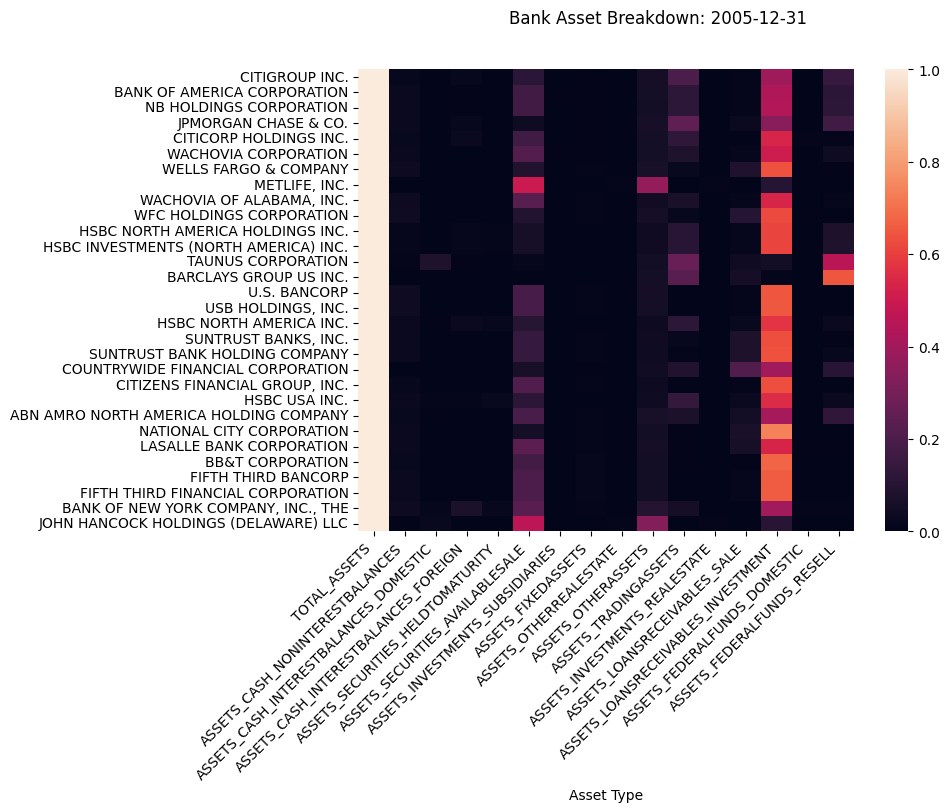

In [ ]:
#print(set(combined_df_2['quarter']))
quarter_date = pd.to_datetime('2005-12-31')

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle(f'Bank Asset Breakdown: {quarter_date.date()}')




heatmap_combined_df = combined_df_2.sort_values(['legal_name','TOTAL_ASSETS', 'year', 'quarter'])
heatmap_combined_df = combined_df_2[(pd.to_datetime(combined_df_2['quarter']) == quarter_date)]
single_hm_df = heatmap_combined_df[heatmap_combined_df['legal_name'] == 'BAYTREE BANCORP, INC.']

filtered_df = heatmap_combined_df.filter(items=assets, axis=1) # axis=1 specifies column filtering
#filtered_df.head()
filtered_df = filtered_df[filtered_df['TOTAL_ASSETS'] > 0]
filtered_df = filtered_df.sort_values('TOTAL_ASSETS', ascending=False)

prop_assets = []
for item in assets[1:]:
    filtered_df[f'proportion_{item}'] = filtered_df[item] / filtered_df['TOTAL_ASSETS']
    #filtered_df[f'{item}'] = filtered_df[item] / filtered_df['TOTAL_ASSETS']
    prop_assets.append(f'proportion_{item}')
    #prop_assets.append(f'{item}')


prop_assets.append('legal_name')
print(prop_assets)

#filtered_df = filtered_df.drop('TOTAL_ASSETS', axis=1)
filtered_df = filtered_df[0:30]
#filtered_df = filtered_df[filtered_df['legal_name'] == 'CITIGROUP INC.']

heat_df = filtered_df.filter(items=prop_assets, axis=1) # axis=1 specifies column filtering
#heat_df = heat_df.drop('proportion_TOTAL_ASSETS')
heat_df = heat_df.set_index('legal_name')
heat_df.columns = heat_df.columns.str.replace('proportion_', '', regex=False)



#heat_df.head()

sns.heatmap(heat_df, ax=ax)
ax.set_ylabel('')
ax.set_xlabel('Asset Type')
for label in ax.get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')



<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


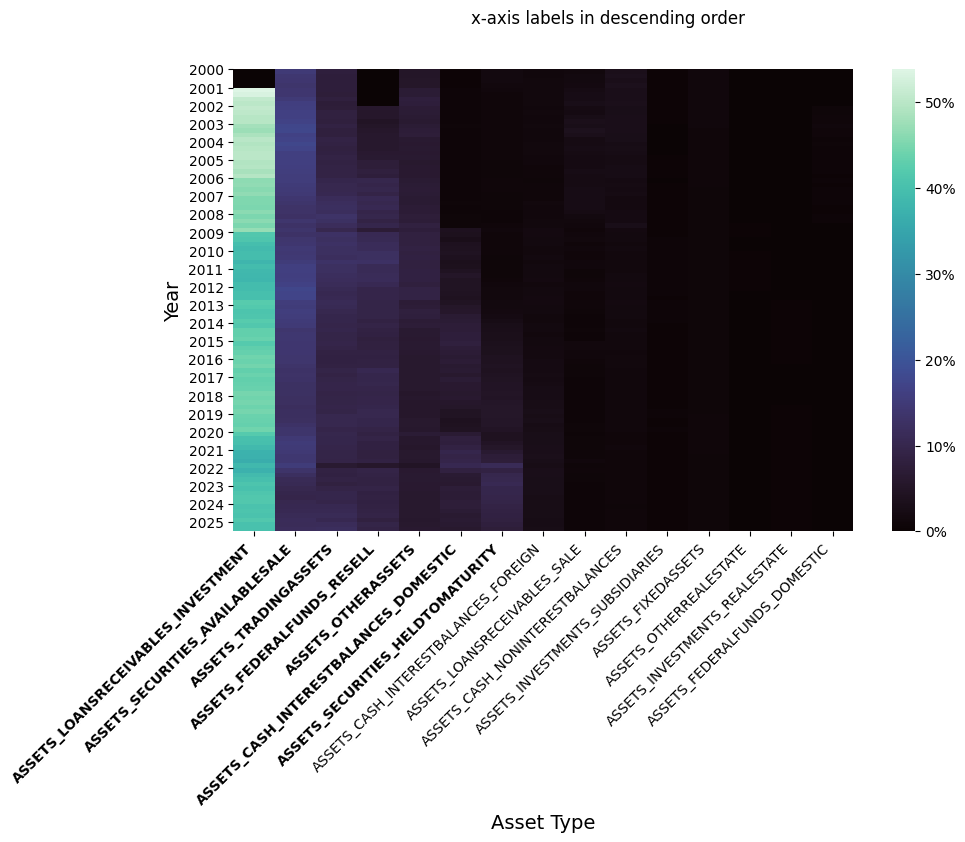

In [ ]:


# sums per quarter
quarter_group_df = (
    combined_df_2[assets]
    .groupby('quarter')
    .sum()
)


# divide each row by that quarter's TOTAL_ASSETS
prop_by_quarter = quarter_group_df.div(quarter_group_df['TOTAL_ASSETS'], axis=0)

print(type(prop_by_quarter.index))


# drop TOTAL_ASSETS (it will just be 1.0 everywhere)
prop_by_quarter = prop_by_quarter.drop(columns=['TOTAL_ASSETS'])


fig, ax = plt.subplots(figsize=(10, 6))



fig.suptitle('x-axis labels are in descending order')
sns.heatmap(prop_by_quarter, ax=ax, cbar_kws={"format": mtick.PercentFormatter(xmax=1.0)},yticklabels=False, cmap='mako')

n = len(prop_by_quarter.index)
step = 4 
prop_by_quarter.index = prop_by_quarter.index.astype(str)
yticks = np.arange(0, n, step)
ylabels = prop_by_quarter.index[::step].str[:4]

ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)

xticklabels = ax.get_xticklabels()
ticks_to_bold = range(0,7)
for tick in ticks_to_bold:
    xticklabels[tick].set_fontweight('bold')


ax.set_ylabel('Year', fontsize = 14)
ax.set_xlabel('Asset Type', fontsize = 14)
for label in ax.get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')


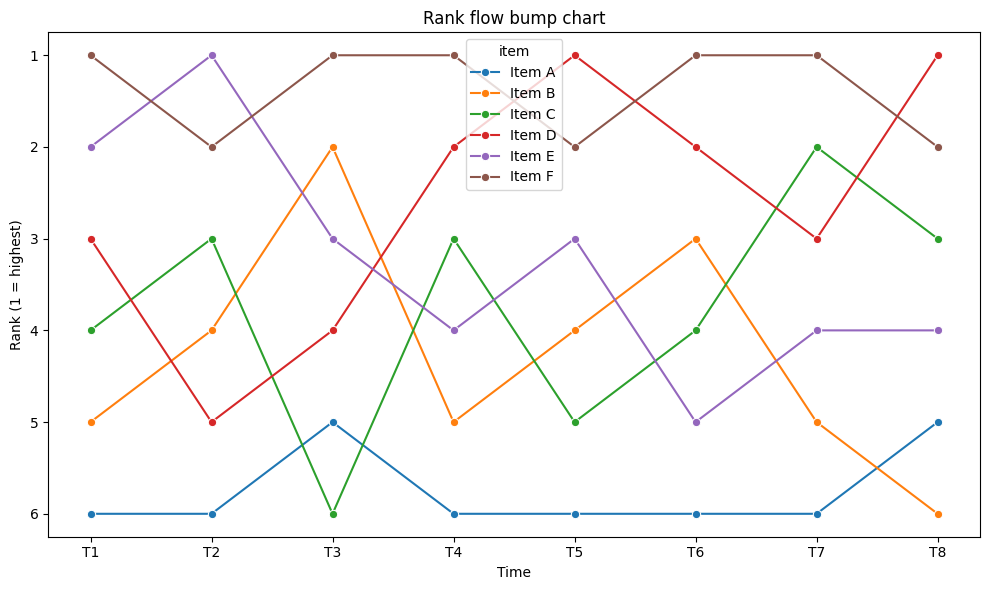

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- fake data: value of 6 items across 8 time points ---
np.random.seed(0)
times = [f"T{i}" for i in range(1, 9)]
items = [f"Item {c}" for c in ["A", "B", "C", "D", "E", "F"]]

rows = []
for t in times:
    for it in items:
        value = np.random.rand() + (items.index(it) * 0.2)  # just to give structure
        rows.append((t, it, value))

df = pd.DataFrame(rows, columns=["time", "item", "value"])

# --- compute rank per time (1 = highest value) ---
df["rank"] = df.groupby("time")["value"].rank(method="first", ascending=False)

# --- bump chart ---
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="time", y="rank", hue="item", marker="o")

plt.gca().invert_yaxis()              # rank 1 at top
plt.xlabel("Time")
plt.ylabel("Rank (1 = highest)")
plt.title("Rank flow bump chart")
plt.tight_layout()
plt.show()


In [21]:
#divide banks into thirds

sorted_by_assets_df = combined_df_2.sort_values(
    ['legal_name', 'TOTAL_ASSETS']
)

num_rows_for_top_third = math.ceil(len(sorted_by_assets_df) / 3)

# Select the top third of the DataFrame

#top_third, middle_third, bottom_third = np.array_split(sorted_by_assets_df, 3)
top_half, bottom_half = np.array_split(sorted_by_assets_df, 2)

#print(set(middle_third['legal_name']))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Text(0, 0.5, 'Charged Off Real Estate ($1000)')

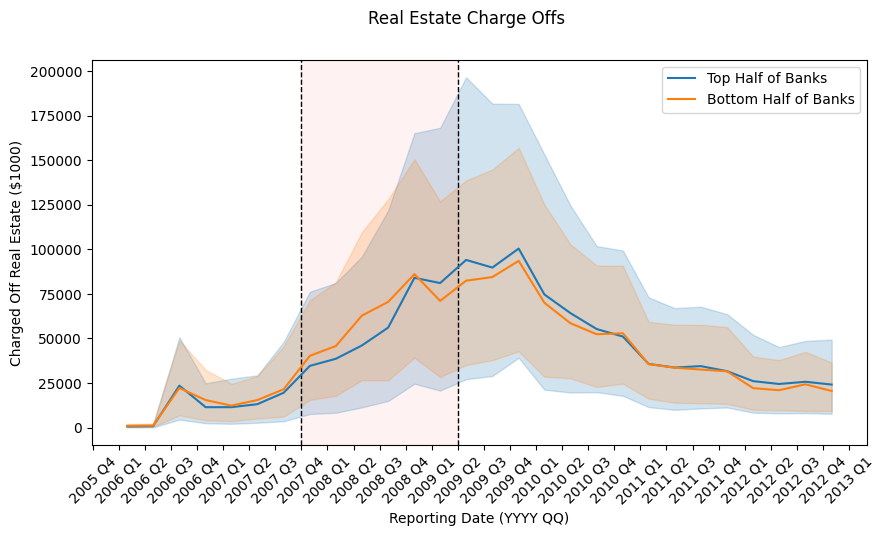

In [24]:



start_date = pd.to_datetime('2006-01-01')
end_date = pd.to_datetime('2013-01-01')
sns_combined_df = combined_df_2.sort_values(['legal_name', 'year', 'quarter'])
sns_combined_df = combined_df_2[(pd.to_datetime(combined_df_2['quarter']) > start_date) & (pd.to_datetime(combined_df_2['quarter']) < end_date)]

#sns_combined_df_top_third = sns_combined_df[sns_combined_df['legal_name'].isin(set(top_third['legal_name']))]
#sns_combined_df_middle_third = sns_combined_df[sns_combined_df['legal_name'].isin(set(middle_third['legal_name']))]
#sns_combined_df_bottom_third = sns_combined_df[sns_combined_df['legal_name'].isin(set(bottom_third['legal_name']))]

sns_combined_df_top_half = sns_combined_df[sns_combined_df['legal_name'].isin(set(top_half['legal_name']))]
sns_combined_df_bottom_half = sns_combined_df[sns_combined_df['legal_name'].isin(set(bottom_half['legal_name']))]

#average_quarterly_income_all = sns_combined_df.groupby(sns_combined_df['quarter'])['Quarterly_NET_INCOME'].mean()
#average_quarterly_sd_all = combined_df.groupby(combined_df['quarter'])['Quarterly_NET_INCOME_FRY9C'].standard()

#filtered_average_quarterly_income = average_quarterly_income_all.iloc[16:44]

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Real Estate Charge Offs')

dates = sns_combined_df['quarter']


# get unique, ordered dates

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

# 2) Format tick labels as "YYYY QX"
def quarter_fmt(x, pos):
    d = mdates.num2date(x)
    q = (d.month - 1) // 3 + 1
    return f"{d.year} Q{q}"

ax.xaxis.set_major_formatter(quarter_fmt)
#xticks = sns_combined_df['quarter'].drop_duplicates().sort_values()

#ax.set_xticks(xticks)
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

y = 'CHARGED_OFF_REAL_ESTATE'

#sns.lineplot(data=sns_combined_df, x='quarter', y=y)

ax.axvline(x=pd.Timestamp("2007-12-01"), color='k', linestyle='--', linewidth=1)
ax.axvline(x=pd.Timestamp("2009-6-01"), color='k', linestyle='--', linewidth=1)

ax.axvspan(pd.Timestamp("2007-12-01"),
           pd.Timestamp("2009-06-01"),
           color='red',
           alpha=0.05)

sns.lineplot(data=sns_combined_df_top_half, x='quarter', y=y, label = 'Top Half of Banks')
sns.lineplot(data=sns_combined_df_bottom_half, x='quarter', y=y, label = 'Bottom Half of Banks')

#sns.lineplot(data=sns_combined_df, x='quarter', y='Quarterly_CHARGED_OFF_REAL_ESTATE')
#sns.lineplot(data=sns_combined_df_top_third, x='quarter', y=y)
#sns.lineplot(data=sns_combined_df_middle_third, x='quarter', y=y)
#sns.lineplot(data=sns_combined_df_bottom_third, x='quarter', y=y)
#sns.lineplot(data=sns_combined_df, x='quarter', y='REVENUE')
#ax.plot(filtered_average_quarterly_income)
#ax.legend()
ax.tick_params(axis='x', rotation=45)
ax.set_xlabel('Reporting Date (YYYY QQ)')
ax.set_ylabel('Charged Off Real Estate ($1000)')




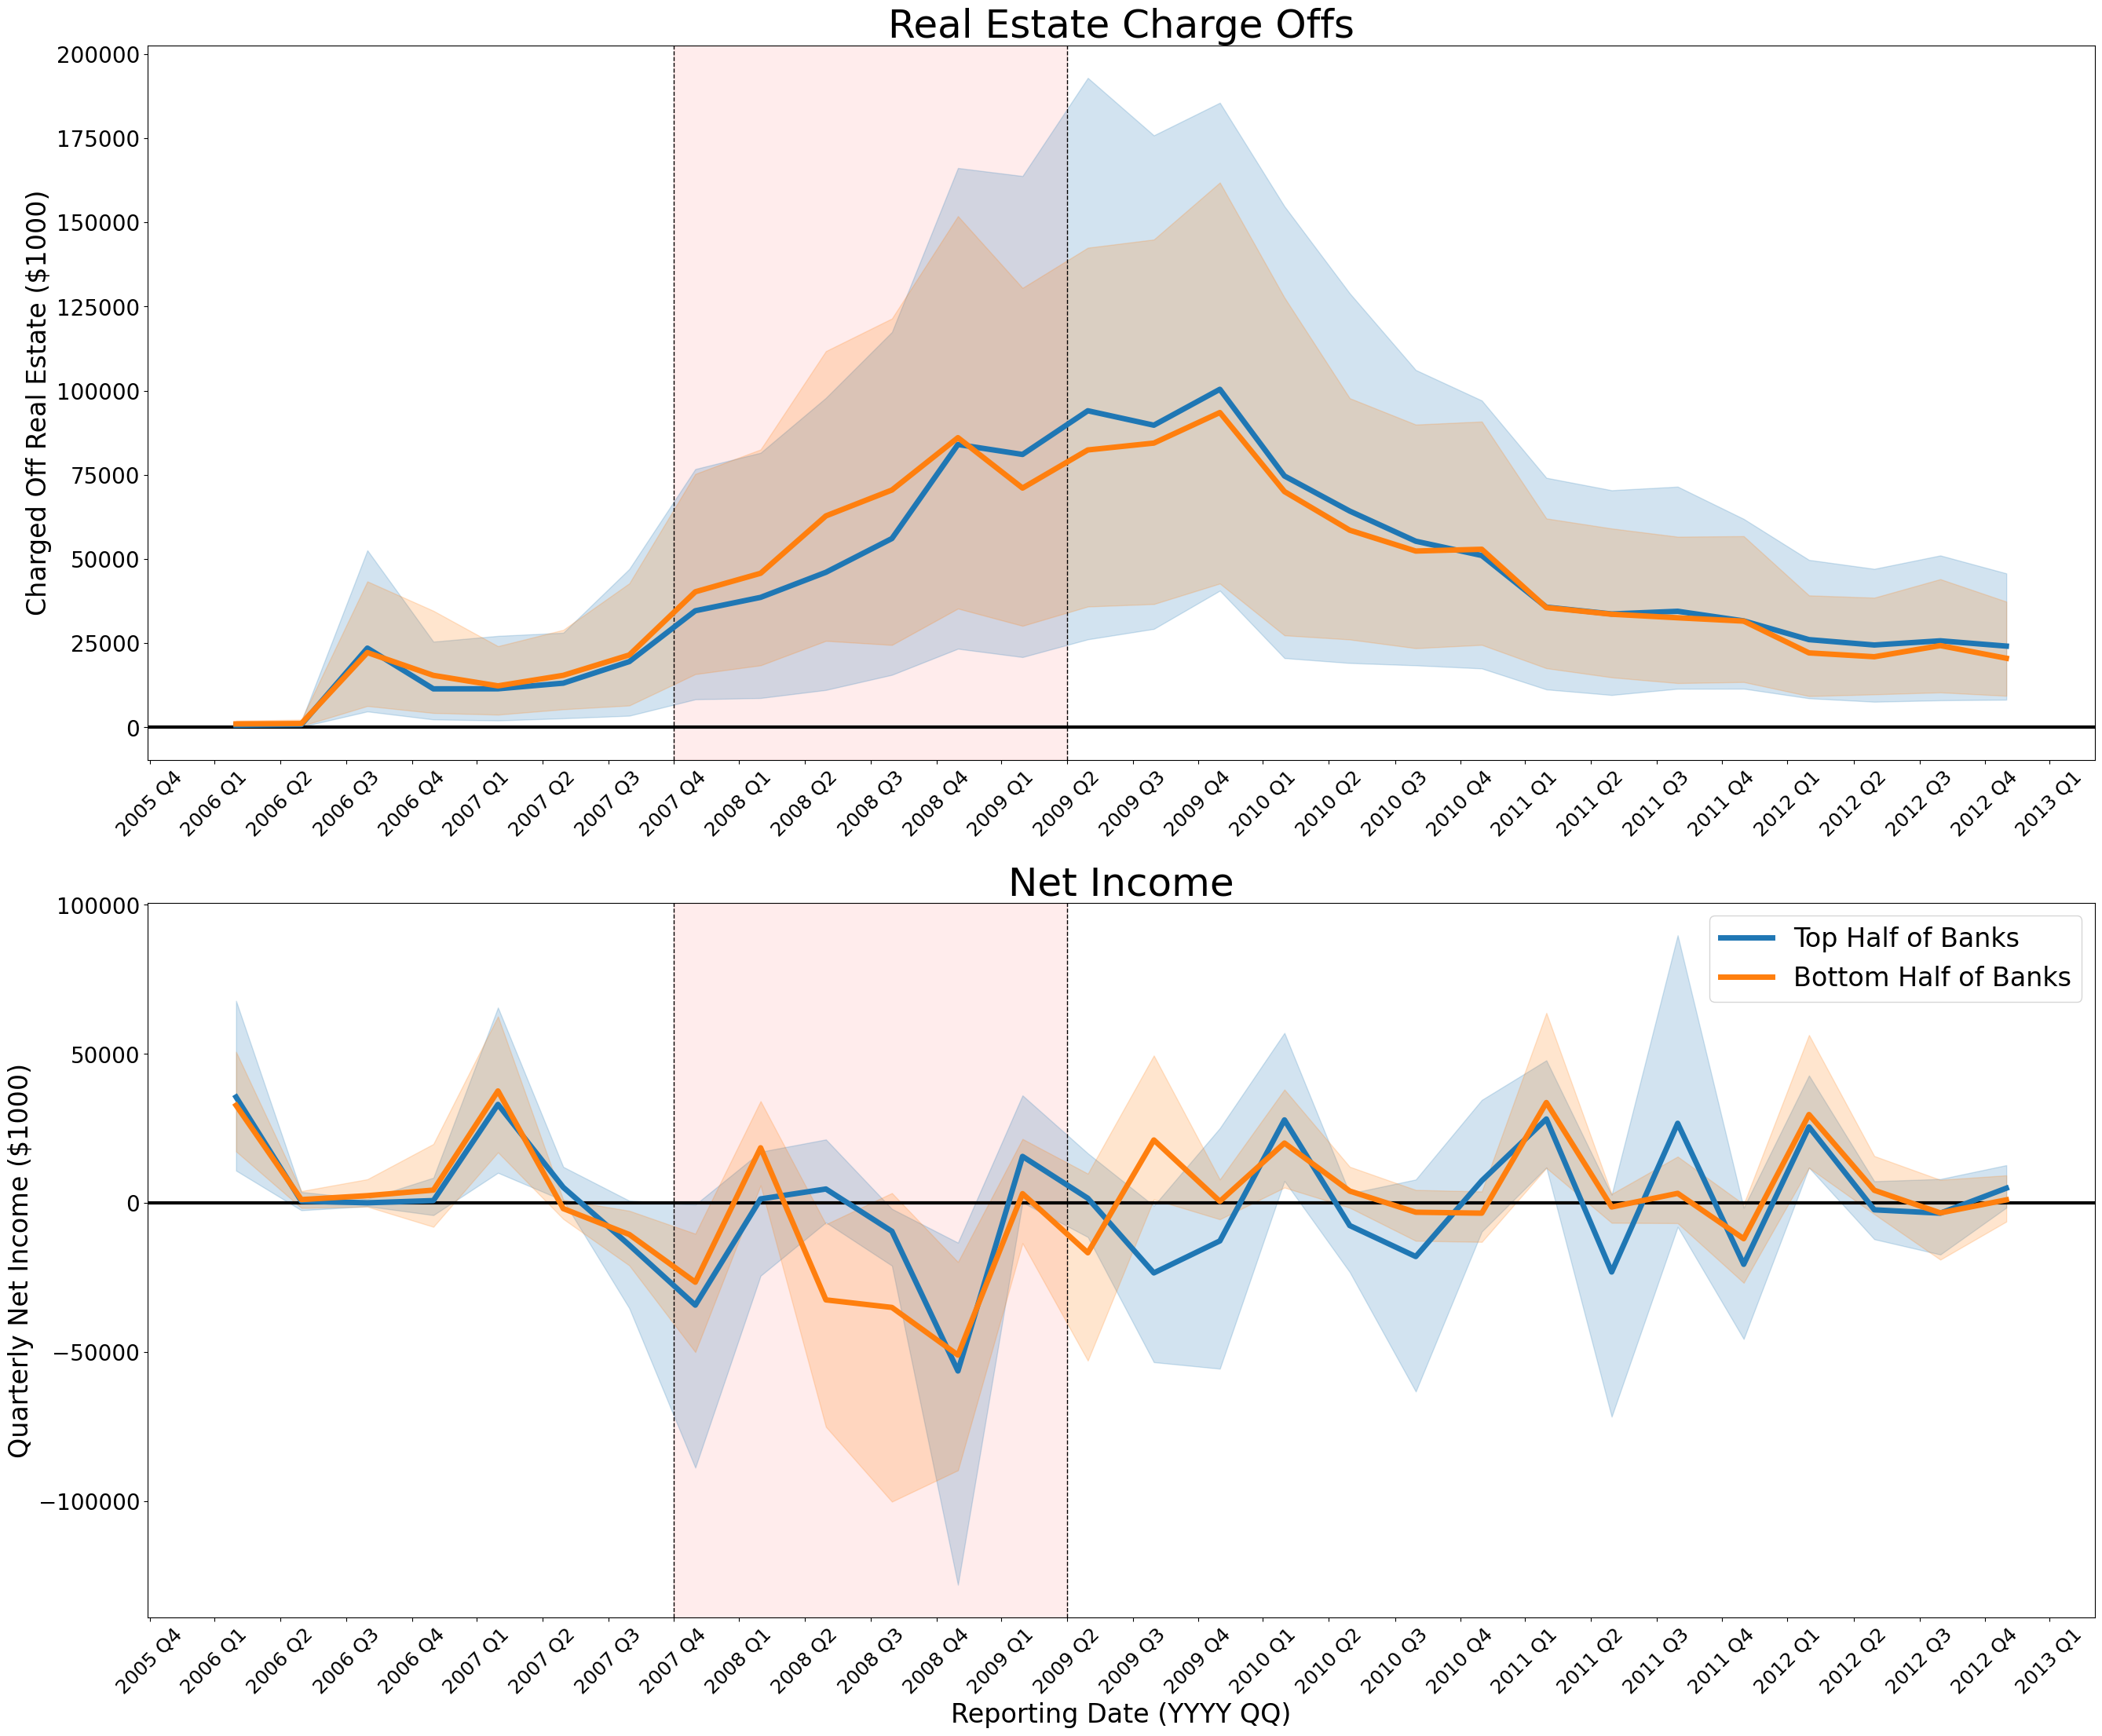

In [25]:
#full figure

import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

start_date = pd.to_datetime('2006-01-01')
end_date = pd.to_datetime('2013-01-01')
sns_combined_df = combined_df_2.sort_values(['legal_name', 'year', 'quarter'])
sns_combined_df = combined_df_2[(pd.to_datetime(combined_df_2['quarter']) > start_date) & (pd.to_datetime(combined_df_2['quarter']) < end_date)]

#sns_combined_df_top_third = sns_combined_df[sns_combined_df['legal_name'].isin(set(top_third['legal_name']))]
#sns_combined_df_middle_third = sns_combined_df[sns_combined_df['legal_name'].isin(set(middle_third['legal_name']))]
#sns_combined_df_bottom_third = sns_combined_df[sns_combined_df['legal_name'].isin(set(bottom_third['legal_name']))]

sns_combined_df_top_half = sns_combined_df[sns_combined_df['legal_name'].isin(set(top_half['legal_name']))]
sns_combined_df_bottom_half = sns_combined_df[sns_combined_df['legal_name'].isin(set(bottom_half['legal_name']))]

#average_quarterly_income_all = sns_combined_df.groupby(sns_combined_df['quarter'])['Quarterly_NET_INCOME'].mean()
#average_quarterly_sd_all = combined_df.groupby(combined_df['quarter'])['Quarterly_NET_INCOME_FRY9C'].standard()

#filtered_average_quarterly_income = average_quarterly_income_all.iloc[16:44]

fig, axes = plt.subplots(figsize=(32, 26), nrows = 2)


dates = sns_combined_df['quarter']

axes[0].set_title('Real Estate Charge Offs', fontsize = 36)
axes[1].set_title('Net Income', fontsize = 36)

axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))

# 2) Format tick labels as "YYYY QX"
def quarter_fmt(x, pos):
    d = mdates.num2date(x)
    q = (d.month - 1) // 3 + 1
    return f"{d.year} Q{q}"

axes[0].xaxis.set_major_formatter(quarter_fmt)
axes[1].xaxis.set_major_formatter(quarter_fmt)
#xticks = sns_combined_df['quarter'].drop_duplicates().sort_values()

#ax.set_xticks(xticks)
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

y = 'CHARGED_OFF_REAL_ESTATE'

#sns.lineplot(data=sns_combined_df, x='quarter', y=y)

axes[0].axvline(x=pd.Timestamp("2007-12-01"), color='k', linestyle='--', linewidth=1)
axes[0].axvline(x=pd.Timestamp("2009-6-01"), color='k', linestyle='--', linewidth=1)
axes[0].axhline(y=0, color='k', linestyle='-', linewidth=3)

axes[0].axvspan(pd.Timestamp("2007-12-01"),
           pd.Timestamp("2009-06-01"),
           color='red',
           alpha=0.075)

axes[1].axvline(x=pd.Timestamp("2007-12-01"), color='k', linestyle='--', linewidth=1)
axes[1].axvline(x=pd.Timestamp("2009-6-01"), color='k', linestyle='--', linewidth=1)
axes[1].axhline(y=0, color='k', linestyle='-', linewidth=3)

axes[1].axvspan(pd.Timestamp("2007-12-01"),
           pd.Timestamp("2009-06-01"),
           color='red',
           alpha=0.075)

sns.lineplot(data=sns_combined_df_top_half, x='quarter', y=y, ax=axes[0], linewidth=5)
sns.lineplot(data=sns_combined_df_bottom_half, x='quarter', y=y, ax=axes[0], linewidth=5)

sns.lineplot(data=sns_combined_df_top_half, x='quarter', y='Quarterly_NET_INCOME', label = 'Top Half of Banks', ax=axes[1], linewidth=5)
sns.lineplot(data=sns_combined_df_bottom_half, x='quarter', y='Quarterly_NET_INCOME', label = 'Bottom Half of Banks', ax=axes[1], linewidth=5)

#sns.lineplot(data=sns_combined_df, x='quarter', y='Quarterly_CHARGED_OFF_REAL_ESTATE')
#sns.lineplot(data=sns_combined_df_top_third, x='quarter', y=y)
#sns.lineplot(data=sns_combined_df_middle_third, x='quarter', y=y)
#sns.lineplot(data=sns_combined_df_bottom_third, x='quarter', y=y)
#sns.lineplot(data=sns_combined_df, x='quarter', y='REVENUE')
#ax.plot(filtered_average_quarterly_income)
#ax.legend()
axes[0].tick_params(axis='x', rotation=45, labelsize = 18)
axes[0].tick_params(axis='y', labelsize = 20)
axes[0].set_xlabel('')
axes[0].set_ylabel('Charged Off Real Estate ($1000)', fontsize = 24)

axes[1].tick_params(axis='x', rotation=45, labelsize = 18)
axes[1].tick_params(axis='y', labelsize = 20)
axes[1].set_xlabel('Reporting Date (YYYY QQ)', fontsize = 24)
axes[1].set_ylabel('Quarterly Net Income ($1000)', fontsize = 24)

plt.legend(fontsize=24)




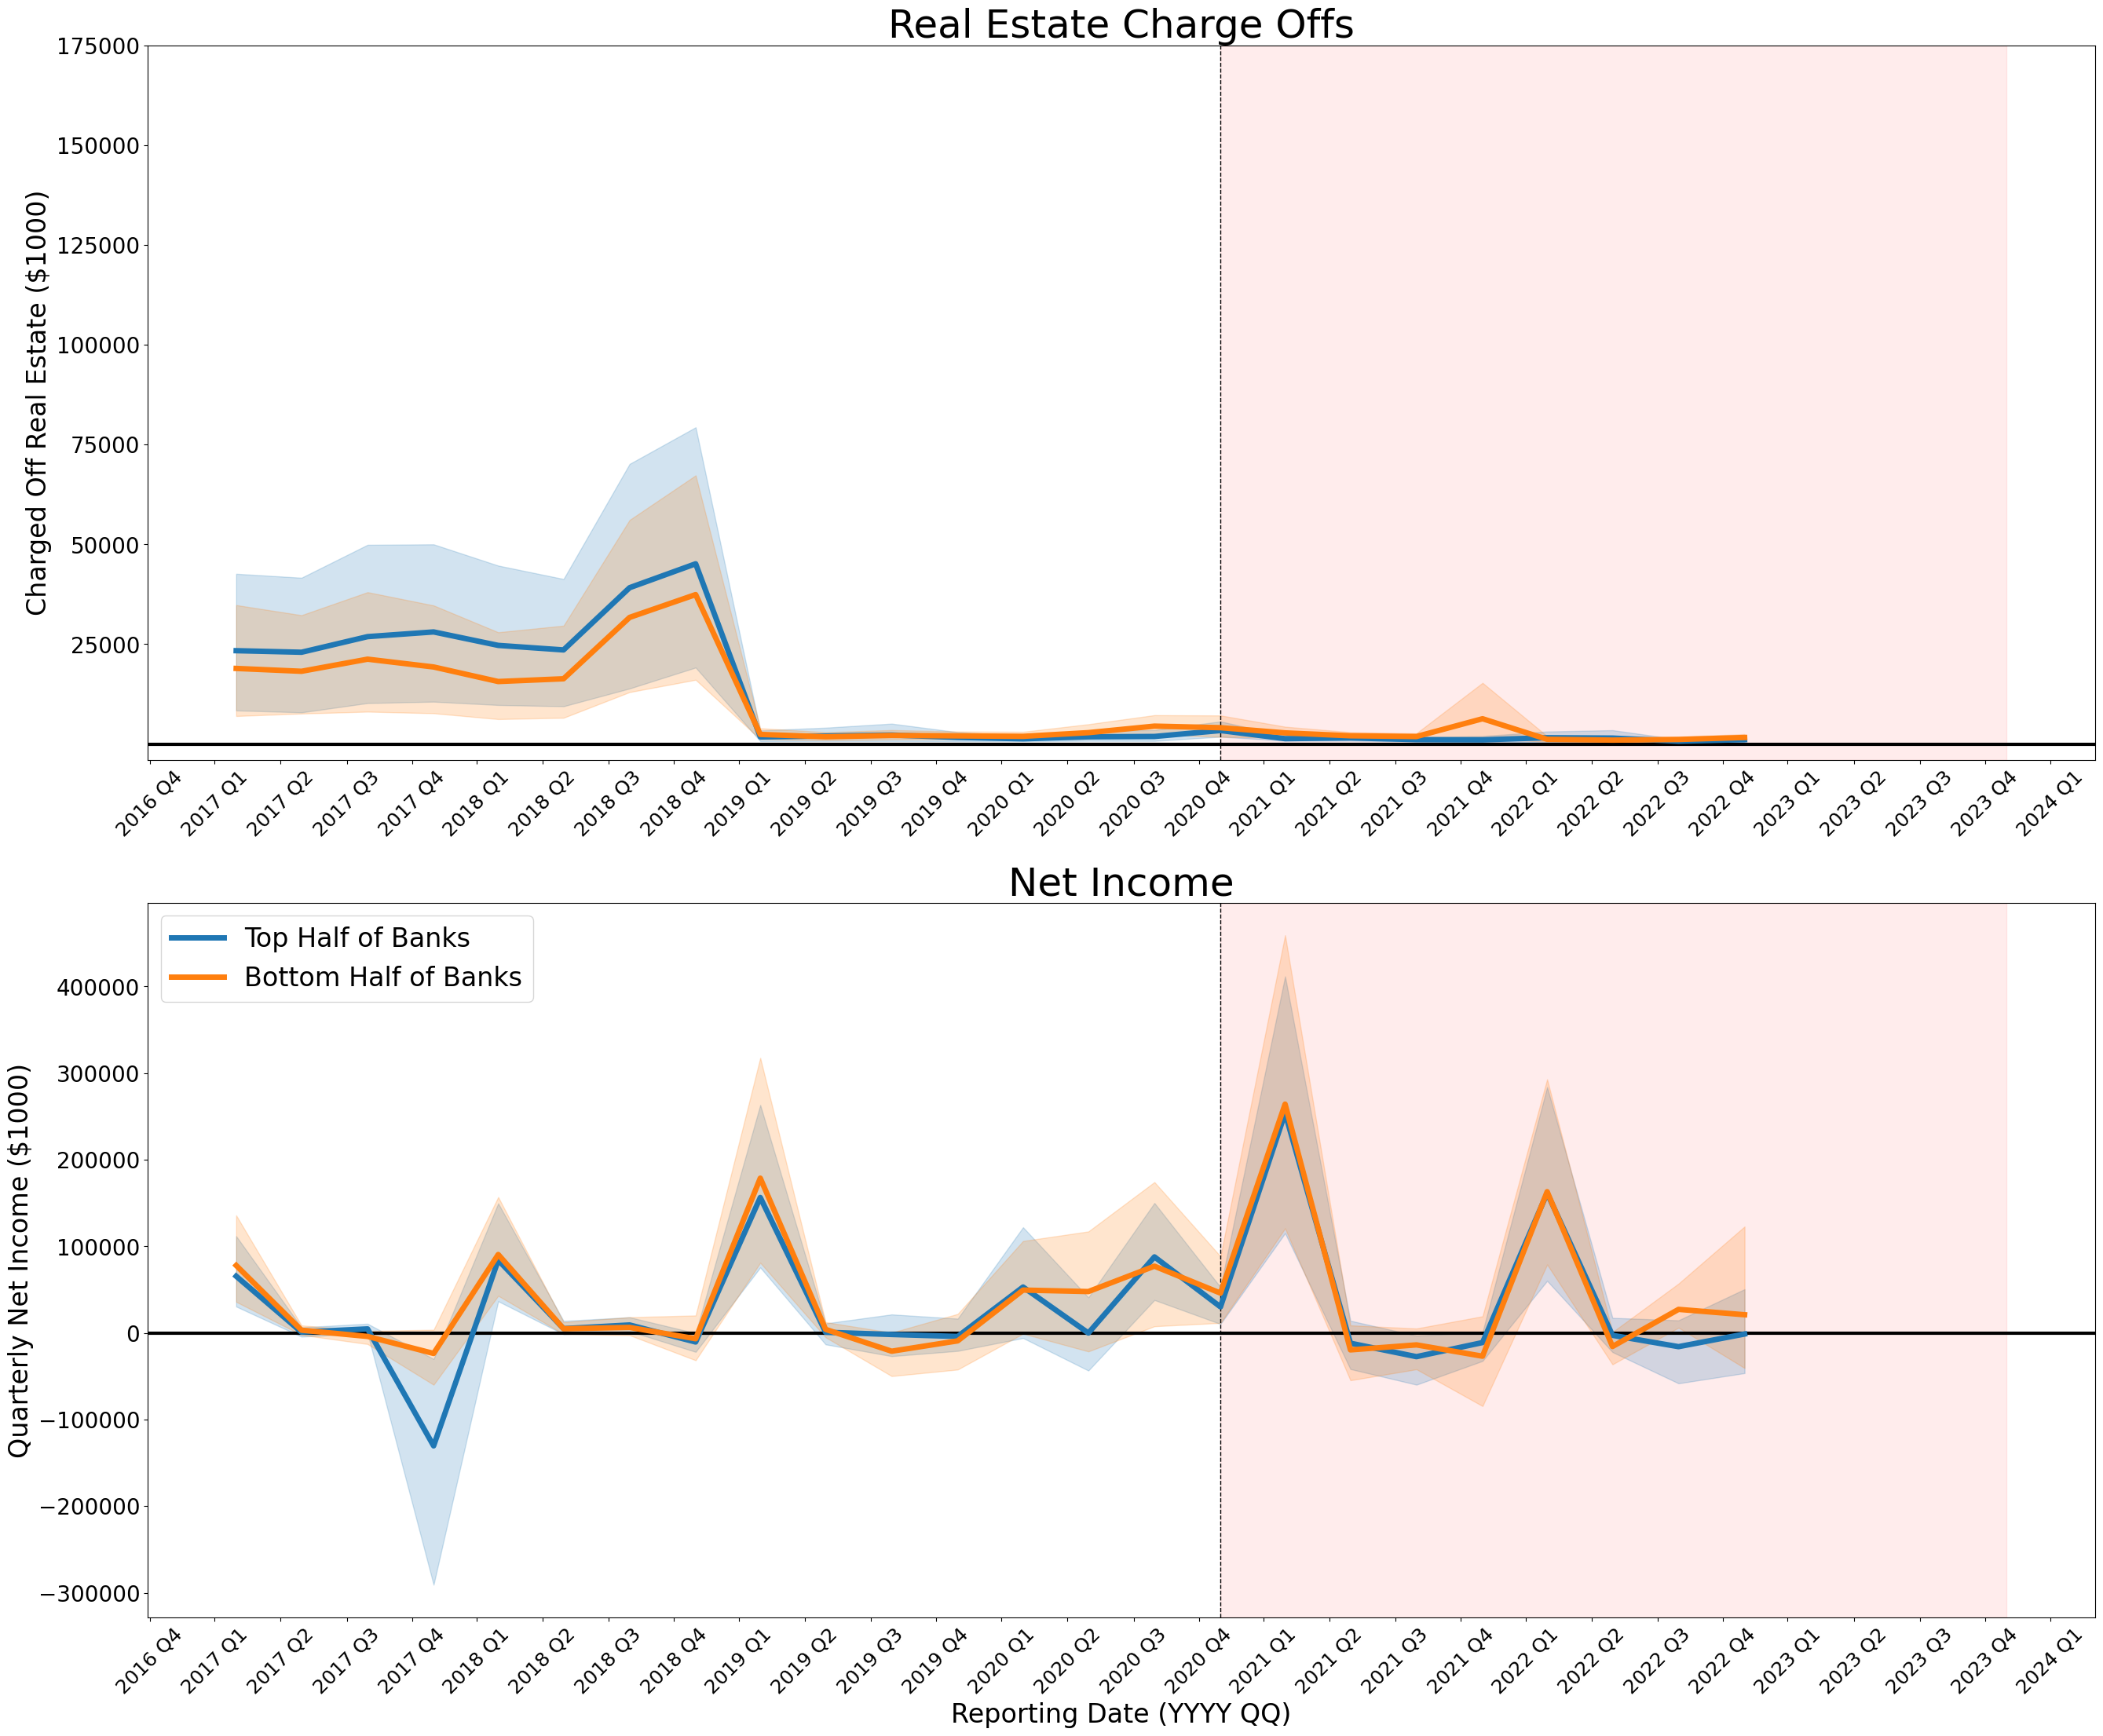

In [26]:
#full figure


start_date = pd.to_datetime('2017-01-01')
end_date = pd.to_datetime('2023-01-01')
sns_combined_df = combined_df_2.sort_values(['legal_name', 'year', 'quarter'])
sns_combined_df = combined_df_2[(pd.to_datetime(combined_df_2['quarter']) > start_date) & (pd.to_datetime(combined_df_2['quarter']) < end_date)]

#sns_combined_df_top_third = sns_combined_df[sns_combined_df['legal_name'].isin(set(top_third['legal_name']))]
#sns_combined_df_middle_third = sns_combined_df[sns_combined_df['legal_name'].isin(set(middle_third['legal_name']))]
#sns_combined_df_bottom_third = sns_combined_df[sns_combined_df['legal_name'].isin(set(bottom_third['legal_name']))]

sns_combined_df_top_half = sns_combined_df[sns_combined_df['legal_name'].isin(set(top_half['legal_name']))]
sns_combined_df_bottom_half = sns_combined_df[sns_combined_df['legal_name'].isin(set(bottom_half['legal_name']))]

#average_quarterly_income_all = sns_combined_df.groupby(sns_combined_df['quarter'])['Quarterly_NET_INCOME'].mean()
#average_quarterly_sd_all = combined_df.groupby(combined_df['quarter'])['Quarterly_NET_INCOME_FRY9C'].standard()

#filtered_average_quarterly_income = average_quarterly_income_all.iloc[16:44]

fig, axes = plt.subplots(figsize=(32, 26), nrows = 2)


dates = sns_combined_df['quarter']

charge_offs_ticks = [25000, 50000, 75000, 100000, 125000, 150000, 175000]

axes[0].set_title('Real Estate Charge Offs', fontsize = 36)
axes[1].set_title('Net Income', fontsize = 36)

axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))

# 2) Format tick labels as "YYYY QX"
def quarter_fmt(x, pos):
    d = mdates.num2date(x)
    q = (d.month - 1) // 3 + 1
    return f"{d.year} Q{q}"

axes[0].xaxis.set_major_formatter(quarter_fmt)
axes[1].xaxis.set_major_formatter(quarter_fmt)
#xticks = sns_combined_df['quarter'].drop_duplicates().sort_values()

#ax.set_xticks(xticks)
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

y = 'CHARGED_OFF_REAL_ESTATE'

#sns.lineplot(data=sns_combined_df, x='quarter', y=y)

#axes[0].axvline(x=pd.Timestamp("2007-12-01"), color='k', linestyle='--', linewidth=1)
#axes[0].axvline(x=pd.Timestamp("2009-6-01"), color='k', linestyle='--', linewidth=1)



#axes[1].axvline(x=pd.Timestamp("2007-12-01"), color='k', linestyle='--', linewidth=1)

axes[0].axvline(x=pd.Timestamp("2020-12-31"), color='k', linestyle='--', linewidth=1)
axes[0].axhline(y=0, color='k', linestyle='-', linewidth=3)
axes[1].axhline(y=0, color='k', linestyle='-', linewidth=3)

axes[0].axvspan(pd.Timestamp("2020-12-31"),
           pd.Timestamp("2023-12-31"),
           color='red',
           alpha=0.075)
axes[1].axvline(x=pd.Timestamp("2020-12-31"), color='k', linestyle='--', linewidth=1)

axes[1].axvspan(pd.Timestamp("2020-12-31"),
           pd.Timestamp("2023-12-31"),
           color='red',
           alpha=0.075)



sns.lineplot(data=sns_combined_df_top_half, x='quarter', y=y, ax=axes[0], linewidth=5)
sns.lineplot(data=sns_combined_df_bottom_half, x='quarter', y=y, ax=axes[0], linewidth=5)

sns.lineplot(data=sns_combined_df_top_half, x='quarter', y='Quarterly_NET_INCOME', label = 'Top Half of Banks', ax=axes[1], linewidth=5)
sns.lineplot(data=sns_combined_df_bottom_half, x='quarter', y='Quarterly_NET_INCOME', label = 'Bottom Half of Banks', ax=axes[1], linewidth=5)

#sns.lineplot(data=sns_combined_df, x='quarter', y='Quarterly_CHARGED_OFF_REAL_ESTATE')
#sns.lineplot(data=sns_combined_df_top_third, x='quarter', y=y)
#sns.lineplot(data=sns_combined_df_middle_third, x='quarter', y=y)
#sns.lineplot(data=sns_combined_df_bottom_third, x='quarter', y=y)
#sns.lineplot(data=sns_combined_df, x='quarter', y='REVENUE')
#ax.plot(filtered_average_quarterly_income)
#ax.legend()
axes[0].set_yticks(charge_offs_ticks)
axes[0].tick_params(axis='x', rotation=45, labelsize = 18)
axes[0].tick_params(axis='y', labelsize = 20)
axes[0].set_xlabel('')
axes[0].set_ylabel('Charged Off Real Estate ($1000)', fontsize = 24)

axes[1].tick_params(axis='x', rotation=45, labelsize = 18)
axes[1].tick_params(axis='y', labelsize = 20)
axes[1].set_xlabel('Reporting Date (YYYY QQ)', fontsize = 24)
axes[1].set_ylabel('Quarterly Net Income ($1000)', fontsize = 24)

plt.legend(fontsize=24)


